# 1. SEE ALL SHEET NAMES FIRST


In [95]:
import pandas as pd
df = pd.read_csv("gillionaire_2026_full_year.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       197 non-null    int64  
 1   customer_name  197 non-null    object 
 2   item           197 non-null    object 
 3   city           197 non-null    object 
 4   amount         194 non-null    float64
 5   order_date     197 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.4+ KB


In [96]:
df.shape

(197, 6)

# HANDLING MISSING VALUES & DUPLICATES

In [97]:
df['amount'].isnull().sum()
df[df['amount'].isnull()]

,order_id,customer_name,item,city,amount,order_date
27,8161,Yaa Asantewaa,Rug,Kumasi,NaN,2026-11-18
57,8021,Grace Ofori,Blinds,Accra,NaN,2026-02-11
128,8096,Grace Ofori,Rug,Accra,NaN,2026-08-17


# DROP ANY ROW WITH MISSING VALUES

In [98]:
df.dropna(subset=['amount'], inplace=True)

# TRIM & PROPER

In [99]:
df['customer_name'] = df['customer_name'].str.strip().str.title()

# CHECK IF MISSING VALUES ARE GONE

In [100]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
order_id         0
customer_name    0
item             0
city             0
amount           0
order_date       0
dtype: int64


# CHECK DUPLICATES

In [101]:
print("\nDuplicates:")
print(df.duplicated().sum())


Duplicates:
3


# REMOVING THE 3 DUPLICATE ROWS

In [102]:
df.drop_duplicates(inplace=True)

# CHECK TRIM WORKED: ANY LEADING/TRAILING SPACES LEFT?

In [103]:
for col in df.select_dtypes(include=['object']).columns:
    has_space = (df[col].astype(str)!= df[col].astype(str).str.strip()).any()
    print(f"Column '{col}' has leading/trailing spaces: {has_space}")

Column 'customer_name' has leading/trailing spaces: False
Column 'item' has leading/trailing spaces: False
Column 'city' has leading/trailing spaces: False
Column 'order_date' has leading/trailing spaces: False


# CHECK PROPER WORKED: SEE UNIQUE VALUES

In [104]:
print("\nUnique values sample:")
for col in ['customer_name', 'item', 'city']:
    if col in df.columns:
        unique_values = df[col].dropna().unique()
        print(f"\nColumn '{col}' unique values sample: {unique_values[:10]}")  # Displaying first 5 unique values


Unique values sample:

Column 'customer_name' unique values sample: ['Kwame Boadu' 'Yaw Owusu' 'Kojo Mensah' 'Grace Ofori' 'Akosua Darko'
 'Kwabena Asante' 'Ama Boateng' 'Yaa Asantewaa' 'Abena Frimpong'
 'Nana Adjei']

Column 'item' unique values sample: ['Wallpaper' 'Cushions' 'Rug' 'Blinds' 'Curtains']

Column 'city' unique values sample: ['Kumasi' 'Accra' 'Tema']


# CHECK DATA TYPE

In [105]:
print("\nData types:")
print(df.dtypes)


Data types:
order_id           int64
customer_name     object
item              object
city              object
amount           float64
order_date        object
dtype: object


# CHECK FINAL LOOK

In [106]:
df.head()

,order_id,customer_name,item,city,amount,order_date
0,8126,Kwame Boadu,Wallpaper,Kumasi,783.98,2026-10-15
1,8067,Yaw Owusu,Cushions,Accra,228.58,2026-06-17
2,8152,Kojo Mensah,Wallpaper,Kumasi,998.47,2026-11-10
3,8146,Grace Ofori,Rug,Accra,398.27,2026-11-21
4,8137,Akosua Darko,Rug,Accra,417.83,2026-10-20


In [107]:
df = pd.read_csv("gillionaire_2026_full_year_cleaned.csv")  

df["order_date"] = pd.to_datetime(df["order_date"], errors='coerce')

# CHECKING FOR BAD DATES

In [108]:
print(df[df["order_date"].isnull()])  # Display rows where conversion failed

Empty DataFrame
Columns: [order_id, customer_name, item, city, amount, order_date]
Index: []


In [109]:
print("Missing:", df.isnull().sum().to_dict())
print("Total orders:", len(df))
print("Total Revenue: GHC", df['amount'].sum())
print("Date range:", df['order_date'].min(), "to", df['order_date'].max())
print("\nTop Cities:", df["city"].value_counts().head(10).to_dict())

Missing: {'order_id': 0, 'customer_name': 0, 'item': 0, 'city': 0, 'amount': 0, 'order_date': 0}
Total orders: 191
Total Revenue: GHC 130572.44999999998
Date range: 2026-01-01 00:00:00 to 2026-12-26 00:00:00

Top Cities: {'Accra': 92, 'Kumasi': 58, 'Tema': 41}


# SAVE

In [110]:
df.to_csv("cleaned_orders.csv", index=False)

# Define High-Value for prediction later


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# top 25% orders = high value

In [112]:
high_value_threshold = df['amount'].quantile(0.75)  # Define a threshold for high-value orders

In [113]:
df['is_high_value'] = (df['amount'] >= high_value_threshold).astype(int)  # Create a binary column for high-value orders
df.to_csv("cleaned_orders.csv", index=False)  # Save the updated DataFrame to a new CSV file
print(f"High-value orders threshold (75th percentile): GHC {high_value_threshold}")

High-value orders threshold (75th percentile): GHC 962.7249999999999


# Which items/customers to prioritize 2027?
# By Item

In [114]:
item_perf = df.groupby('item')['amount'].agg(['sum', 'count','mean']).sort_values(by='sum', ascending=False)
print("\nItem Performance:\n", item_perf.head(10))


Item Performance:
                 sum  count         mean
item                                   
Blinds     57785.89     54  1070.109074
Wallpaper  29346.23     34   863.124412
Curtains   20021.72     27   741.545185
Rug        16697.52     39   428.141538
Cushions    6721.09     37   181.651081


# By Customer - RFM style

In [115]:
customer_perf = df.groupby('customer_name')['amount'].agg(['sum', 'count','mean']).sort_values(by='sum', ascending=False)
print("\nCustomer Performance:\n", customer_perf.head(10))


Customer Performance:
                      sum  count        mean
customer_name                              
Abena Frimpong  13729.79     18  762.766111
Yaw Owusu       12207.87     19  642.519474
Kobina Essien   11158.22     17  656.365882
Nana Adjei      11098.77     13  853.751538
Afia Serwaa      9809.71     12  817.475833
Adjoa Nyarko     8488.40     12  707.366667
Kwabena Asante   8266.80     11  751.527273
Yaa Asantewaa    7884.77     13  606.520769
Kojo Mensah      7747.33     13  595.948462
Efua Owusu       7313.77      9  812.641111


# STATISTICAL CHECK - Is city difference real or noise?

In [116]:
from scipy import stats

# Get amounts per city

In [117]:
cities = [group['amount'].values for name, group in df.groupby('city')]

# ANOVA test

In [118]:
f_stat, p_value = stats.f_oneway(*cities)
print(f"ANOVA F-statistic: {f_stat}, p-value: {p_value}")

ANOVA F-statistic: 1.6431421429444912, p-value: 0.19613617668775002


In [119]:
if p_value < 0.05:
    print("There is a statistically significant difference in average order amounts between cities.")
else:
    print("There is no statistically significant difference in average order amounts between cities.")

There is no statistically significant difference in average order amounts between cities.


# SEASONAL PATTERNS

In [120]:
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
monthly = df.groupby('month_name')['amount'].agg(['sum', 'count','mean']).reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])   
print("\nMonthly Performance:\n", monthly)


Monthly Performance:
                  sum  count        mean
month_name                             
January      8744.22     12  728.685000
February     7082.15      8  885.268750
March        8836.90     13  679.761538
April        9690.16     15  646.010667
May          7626.18     15  508.412000
June        11808.67     16  738.041875
July        11169.53     15  744.635333
August       7311.40     14  522.242857
September   11398.42     15  759.894667
October     13881.07     18  771.170556
November    14209.90     23  617.821739
December    18813.85     27  696.809259


# Plot

<Axes: title={'center': 'Monthly Revenue'}, xlabel='Month', ylabel='Revenue (GHC)'>

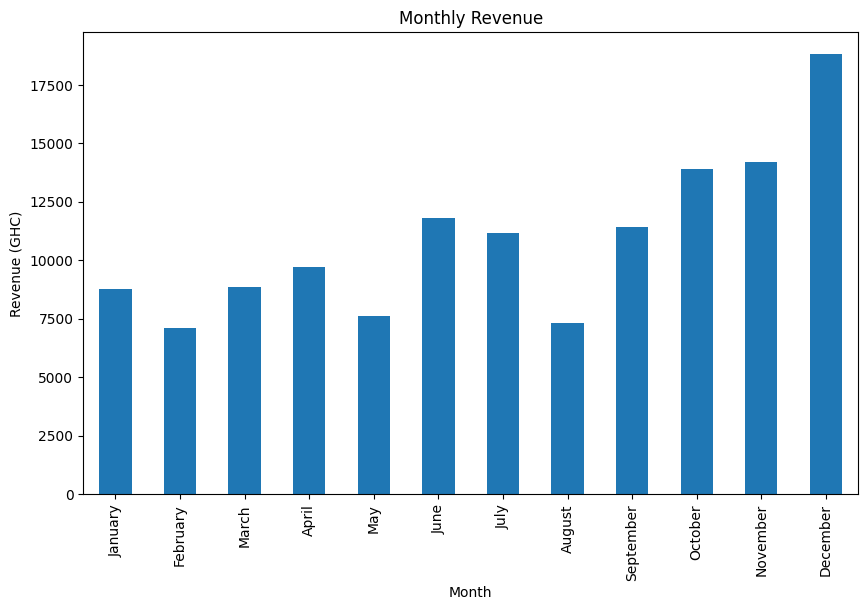

In [121]:
monthly['sum'].plot(kind='bar', title='Monthly Revenue', ylabel='Revenue (GHC)', xlabel='Month', figsize=(10, 6))

# CHURN - Who hasn't ordered recently?

In [122]:
today = df['order_date'].max()
last_order = df.groupby('customer_name')['order_date'].max().reset_index()
last_order['days_since_last_order'] = (today - last_order['order_date']).dt.days


# At risk = no order in last 30 days

In [123]:
at_risk = last_order[last_order['days_since_last_order'] > 30].sort_values('days_since_last_order', ascending=False)  # Customers who haven't ordered in the last 30 days
print("\nAt-Risk Customers (no orders in the last 30 days):\n", at_risk.head(20))


At-Risk Customers (no orders in the last 30 days):
    customer_name order_date  days_since_last_order
1   Adjoa Nyarko 2026-10-24                     63
4    Ama Boateng 2026-11-19                     37
10   Kwame Boadu 2026-11-23                     33


# Add what they usually buy + how much they spent

In [126]:
churn_detail = df.groupby('customer_name').agg(last_order=('order_date', 'max'), total_orders=('order_id', 'count'), total_revenue=('amount', 'sum'), favorite_item=('item', lambda x: x.mode()[0])).reset_index()
churn_detail['days_since_last_order'] = (
    df['order_date'].max() - churn_detail['last_order']
).dt.days
at_risk_customers = churn_detail[churn_detail['days_since_last_order'] > 30].sort_values('days_since_last_order', ascending=False)
print("\nDetailed At-Risk Customers:\n", at_risk_customers.head(20))


Detailed At-Risk Customers:
    customer_name last_order  total_orders  total_revenue favorite_item  \
1   Adjoa Nyarko 2026-10-24            12        8488.40      Curtains   
4    Ama Boateng 2026-11-19            11        6447.07           Rug   
10   Kwame Boadu 2026-11-23             9        5880.32        Blinds   

    days_since_last_order  
1                      63  
4                      37  
10                     33  


In [127]:
active_vip = churn_detail[churn_detail['days_since_last_order'] <= 30].sort_values('total_revenue', ascending=False)
print(active_vip.head(5))

     customer_name last_order  total_orders  total_revenue favorite_item  \
0   Abena Frimpong 2026-12-20            18       13729.79        Blinds   
14       Yaw Owusu 2026-12-19            19       12207.87           Rug   
7    Kobina Essien 2026-12-24            17       11158.22        Blinds   
12      Nana Adjei 2026-12-05            13       11098.77        Blinds   
2      Afia Serwaa 2026-12-08            12        9809.71        Blinds   

    days_since_last_order  
0                       6  
14                      7  
7                       2  
12                     21  
2                      18  


# PREDICTIVE - Will new order be high-value?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Simple features: city, item, month, day of week

In [ ]:
df['month'] = df['order_date'].dt.month
df['daysofweek'] = df['order_date'].dt.dayofweek

x = pd.get_dummies(df[['city','item','month', 'daysofweek']], drop_first=True)  # One-hot encoding for categorical features
y = df['is_high_value']  # Target variable
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   
model = RandomForestClassifier(random_state=42)   
model.fit(x_train, y_train)
    
print("Accuracy:", model.score(x_test, y_test))

Accuracy: 0.8461538461538461


In [128]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df['month'] = df['order_date'].dt.month
df['dayofweek'] = df['order_date'].dt.dayofweek

# DROP ITEM - this is the ablation
X = pd.get_dummies(df[['city','month','dayofweek']], drop_first=True)
y = df['is_high_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy WITHOUT item:", model.score(X_test, y_test))

Accuracy WITHOUT item: 0.717948717948718
